# Experiments with a Simple ResNet on CIFAR-10

This notebook contains various experiments and analyses using the custom **ResNet** implementation defined in `src/resnet_keras.py`.

## Table of Contents

1. Brief description of the architecture.
2. Loading the model and trained weights.
3. Evaluation on the test set.
4. Visualization of metrics and training curves.
5. Inspection of predictions and error analysis.

## Imports

In [ ]:
import tensorflow as tf
from pathlib import Path
import sys
import os
from google.colab import drive

drive.mount('/content/drive')

PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/ResNets")
os.chdir(PROJECT_ROOT)

sys.path.append(str(PROJECT_ROOT / "src"))

from resnet_keras import build_resnet50
DATA_DIR = PROJECT_ROOT / "data"

print("TensorFlow version:", tf.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow version: 2.19.0


## Training visualization functions

In [ ]:
!pip install livelossplot

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from livelossplot import PlotLossesKeras

class RealTimeVisualizer(tf.keras.callbacks.Callback):
    def __init__(self, validation_ds):
        super().__init__()
        self.val_images, self.val_labels = next(iter(validation_ds.take(1)))
        self.class_names = ['avión', 'auto', 'pájaro', 'gato', 'ciervo',
                            'perro', 'rana', 'caballo', 'barco', 'camión']

    def on_epoch_end(self, epoch, logs=None):
        preds = self.model.predict(self.val_images, verbose=0)

        plt.figure(figsize=(15, 3))
        for i in range(5):
            plt.subplot(1, 5, i+1)
            img = self.val_images[i].numpy()
            if img.max() <= 1.0: img = (img * 255).astype(np.uint8)

            plt.imshow(img.astype(np.uint8))

            p_idx, r_idx = np.argmax(preds[i]), np.argmax(self.val_labels[i])
            color = 'green' if p_idx == r_idx else 'red'

            plt.title(f"P: {self.class_names[p_idx]}\nR: {self.class_names[r_idx]}", color=color)
            plt.axis('off')
        plt.show()

## Load weights from path

In [ ]:
model = build_resnet50(input_shape=(160, 160, 3), classes=10)

weights_path = PROJECT_ROOT / "resnet_model.h5"

model = tf.keras.models.load_model(weights_path)

print(f"Model loaded from: {weights_path}")

Modelo cargado desde /content/drive/MyDrive/Colab Notebooks/ResNets/small_resnet_keras.h5


## Train with dataset CIFAR-10

In [ ]:
from train_keras import train_with_cifar, CONFIG

CONFIG["epochs"] = 20
CONFIG["learning_rate"] = 0.05
CONFIG["batch_size"] = 64

history, model = train_with_cifar(
    config=CONFIG,
    project_path=str(PROJECT_ROOT)
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Initializing new model...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 530ms/step - accuracy: 0.1694 - loss: 4.4441
Epoch 1: val_accuracy improved from None to 0.20450, saving model to /content/drive/MyDrive/Colab Notebooks/ResNets/checkpoints/resnet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Colab Notebooks/ResNets/checkpoints/resnet_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 479s 571ms/step - accuracy: 0.2107 - loss: 2.4896 - val_accuracy: 0.2045 - val_loss: 2.0655 - learning_rate: 0.0500
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 543ms/step - accuracy: 0.2713 - loss: 1.9278
Epoch 2: val_accuracy improved from 0.20450 to 0.28710, saving model to /content/drive/MyDrive/Colab Notebooks/ResNets/checkpoints/resnet_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Colab Notebooks/ResNets/checkpoints/resnet_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 448s 573ms/step - accuracy: 0.2816 - loss: 1.9141 - 

## Resume training from loaded model

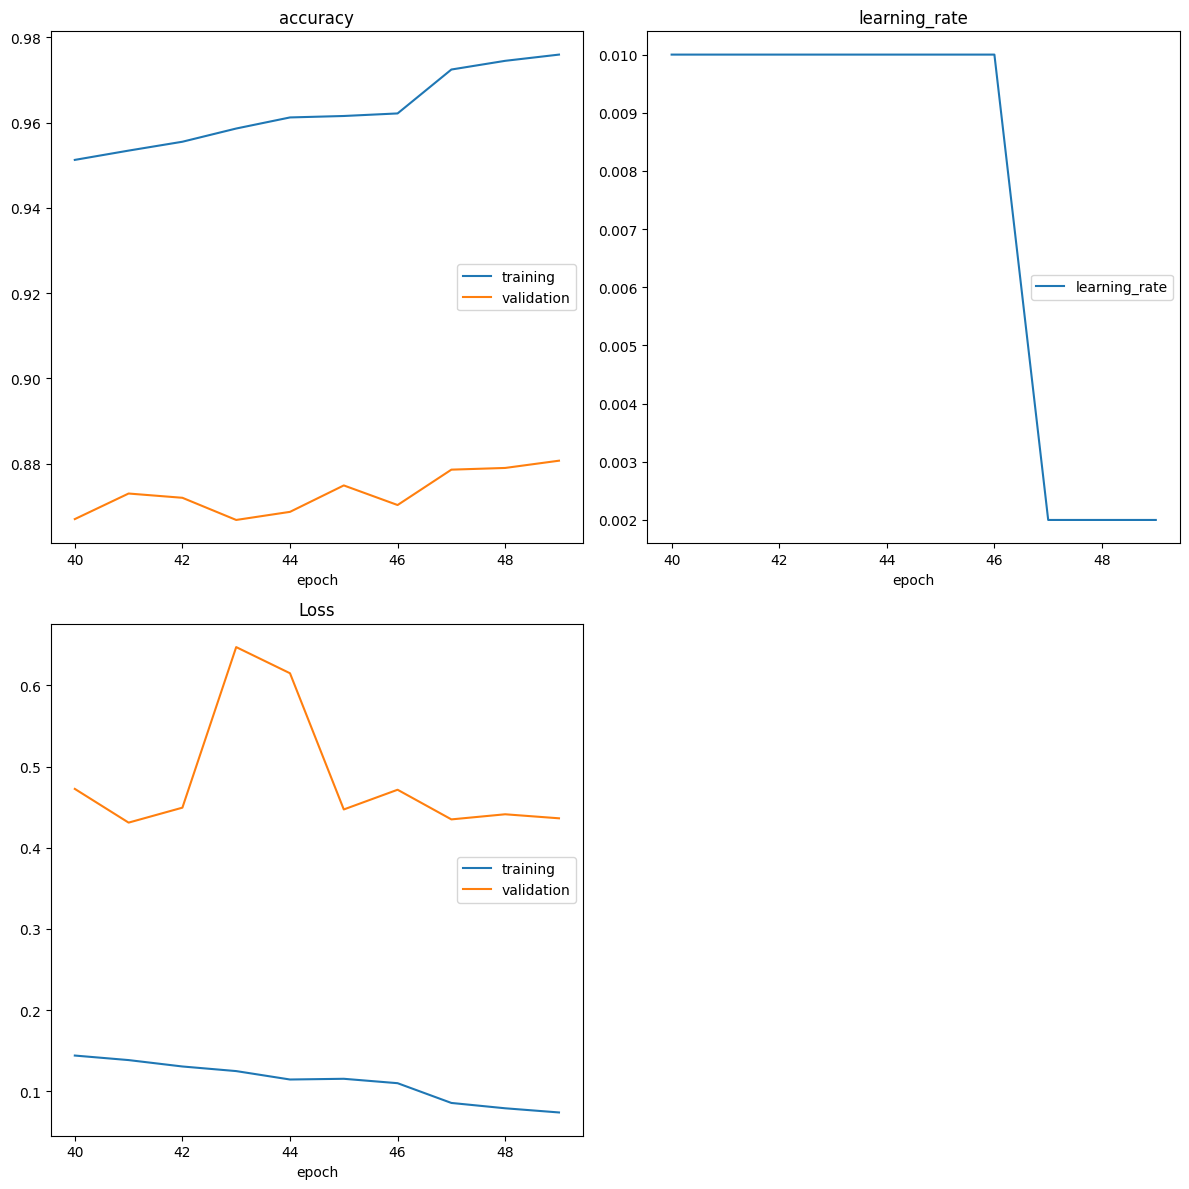

accuracy
	training         	 (min:    0.951, max:    0.976, cur:    0.976)
	validation       	 (min:    0.867, max:    0.881, cur:    0.881)
learning_rate
	learning_rate    	 (min:    0.002, max:    0.010, cur:    0.002)
Loss
	training         	 (min:    0.074, max:    0.144, cur:    0.074)
	validation       	 (min:    0.431, max:    0.647, cur:    0.436)
782/782 ━━━━━━━━━━━━━━━━━━━━ 459s 587ms/step - accuracy: 0.9760 - loss: 0.0738 - val_accuracy: 0.8807 - val_loss: 0.4362 - learning_rate: 0.0020
Epoch 50: early stopping
Restoring model weights from the end of the best epoch: 42.


In [ ]:
from tensorflow.keras.models import load_model
from train_keras import train_with_cifar, CONFIG, get_cifar10_dataset

weights_path = "/content/drive/MyDrive/Colab Notebooks/ResNets/checkpoints/resnet_best.keras"
model = load_model(weights_path)

CONFIG["epochs"] = 80
CONFIG["initial_epoch"] = 40
CONFIG["learning_rate"] = 0.01
CONFIG["batch_size"] = 64

_, val_ds = get_cifar10_dataset(
    batch_size=CONFIG["batch_size"],
    target_size=CONFIG["target_size"]
)

visualizadores = [
    PlotLossesKeras(),
]


history, model = train_with_cifar(
    model=model,
    config=CONFIG,
    project_path=str(PROJECT_ROOT),
    extra_callbacks=visualizadores
)

## Test Evaluation

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_test = x_test.astype("float32") / 255.0
x_test = tf.image.resize(x_test, (160, 160))

# One-hot encoding de las etiquetas
num_classes = 10
y_test_cat = tf.keras.utils.to_categorical(y_test, num_classes)

# eval
test_loss, test_acc = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")

Test loss: 0.4309
Test accuracy: 0.8730
